# **Gradient Boosting Classification**

In [25]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import make_classification
from sklearn.metrics import mean_squared_error, accuracy_score

import warnings
warnings.filterwarnings('ignore')

In [26]:
X_data, y_data = make_classification(
    n_samples=1000,
    n_features=5,
    n_classes=3,
    n_clusters_per_class=1,
    random_state=42
)

df = pd.DataFrame(X_data, columns=[f'feature_{i}' for i in range(5)])
df['target'] = y_data


X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,target
0,0.789678,0.875056,-0.524088,1.108592,-1.402916,0
1,-1.686931,3.324227,-0.190503,3.101080,-3.083091,2
2,-1.070137,2.950171,0.508269,2.853285,-2.940819,2
3,0.103687,-1.319036,-1.352670,-1.364504,1.494486,1
4,-1.309502,1.750843,-0.557423,1.533576,-1.422048,2


In [27]:
# making the model
gbc = GradientBoostingClassifier(
    n_estimators=1000,
    learning_rate=0.1,
    random_state=42,
    max_depth=5,
    loss='log_loss',
    # alpha=0.9,            # classifier doesn't take alpha
    n_iter_no_change=10,
    validation_fraction=0.2,
    tol=0.001
)

# training the model
gbc.fit(X_train, y_train)
y_pred = gbc.predict(X_test)

print(f"MSE : {mean_squared_error(y_test, y_pred)}")
print(f"ACCURACY : {accuracy_score(y_test, y_pred)}")

print(f"The model stopped training after {gbc.n_estimators_} iterations.")


MSE : 0.155
ACCURACY : 0.905
The model stopped training after 35 iterations.


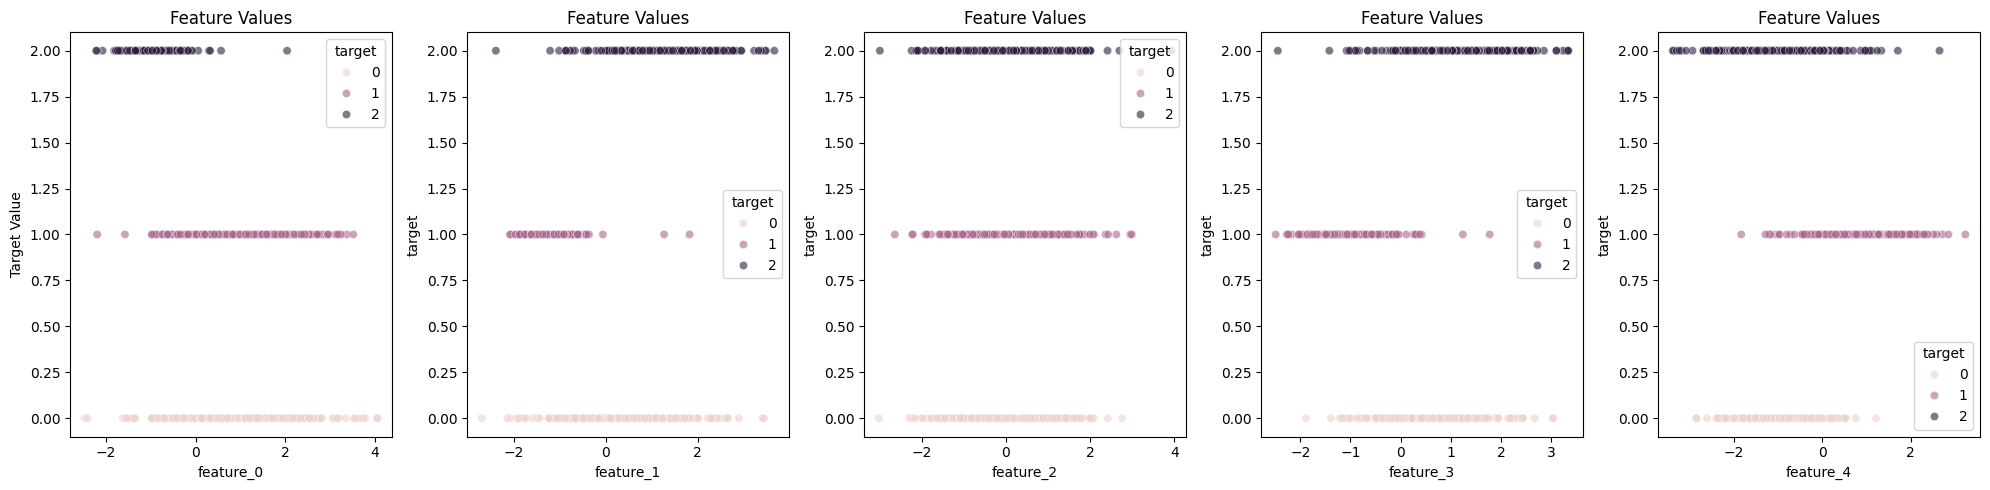

In [28]:
# plotting the graph

train_df = X_train.copy()
train_df['target'] = y_train

fig, axes = plt.subplots(1,5,figsize=(20,5))

for i, col in enumerate(X.columns):
    sns.scatterplot(ax=axes[i], x=train_df[col], y=train_df['target'], alpha=0.6, hue=train_df['target'])
    axes[i].set_title(f"{col} vs Target")
    axes[i].set_title(f"Feature Values")

    if i == 0:
        axes[i].set_ylabel('Target Value')

plt.tight_layout()
plt.show()

FEATURE IMPORTANCE : 
feature_0    0.50452
feature_1    0.30031
feature_2    0.02317
feature_3    0.03372
feature_4    0.13828
dtype: float64


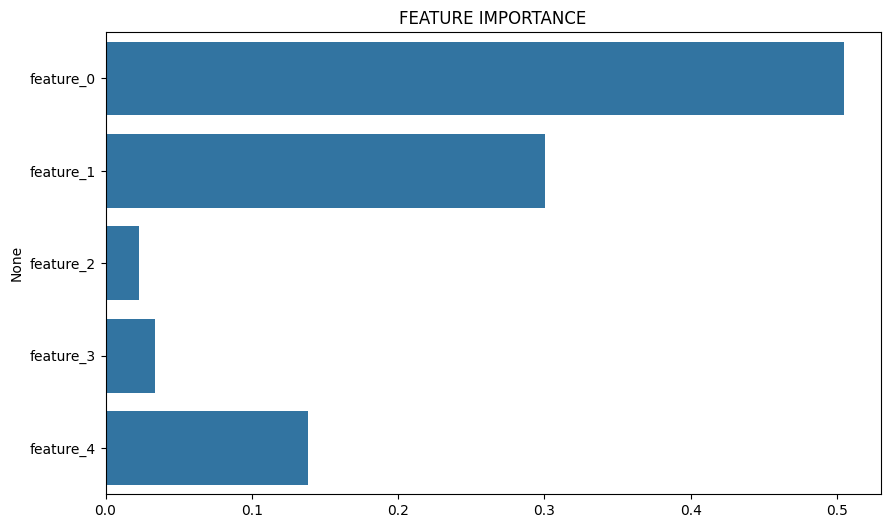

In [29]:
# checking for feature importance
print(f"FEATURE IMPORTANCE : \n{pd.Series(gbc.feature_importances_, index=X.columns)}")

plt.figure(figsize=(10,6))
sns.barplot(x=gbc.feature_importances_, y=X.columns)
plt.title("FEATURE IMPORTANCE")
plt.show()